In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/salary-dataset-simple-linear-regression/Salary_dataset.csv


# Importing all important libraries 


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as ex
import plotly.graph_objects as gb
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/mpfordreamer/regression-practice/main/dataset/Salary-dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


# checking the non-null count along with datatype for each column


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 848.0 bytes


# checking for unique values to decide if we need to drop any column


In [5]:
df.nunique()


Unnamed: 0         30
YearsExperience    28
Salary             30
dtype: int64

 # Visualizing the dataset properly


In [6]:
fig=ex.scatter(data_frame=df,x="YearsExperience",y="Salary",size="YearsExperience",trendline='ols')
fig.show()

# Dropping the unnamed column that was used for indexing purpose


In [7]:
df.drop('Unnamed: 0', axis=1, inplace=True)


# checking the information about the dataframe


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


# Extracting features and target variable from the dataframe 'df'


In [9]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

# splitting the data into train and test data


In [10]:
(X_train, X_test, y_train, y_test) = train_test_split(X, y, test_size=0.2, random_state=42)


# Fitting the model


In [11]:
lr=LinearRegression().fit(X_train,y_train)
lr

LinearRegression()

# making predictions on Train and Test data


In [12]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)


# Determining the metrics for Linear Regression


In [13]:
train_rme=mean_squared_error(y_train,y_train_pred)
test_rme=mean_squared_error(y_test,y_test_pred)
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)
print(f"train_rme: {train_rme}\n"
      f"test_rme: {test_rme}\n"
      f"train_r2: {train_r2}\n"
      f"test_r2: {test_r2}")

train_rme: 27102249.73126133
test_rme: 49830096.855908394
train_r2: 0.9645401573418148
test_r2: 0.9024461774180497


 # Create DataFrames for training and testing datasets


In [14]:
train_data = pd.DataFrame({'Actual': y_train.ravel(), 'Predicted': y_train_pred.ravel(), 'Dataset': 'Training'})
test_data = pd.DataFrame({'Actual': y_test.ravel(), 'Predicted': y_test_pred.ravel(), 'Dataset': 'Testing'})

# Concatenate both DataFrames
combined_data = pd.concat([train_data, test_data], ignore_index=True)

# Plot the results using Seaborn


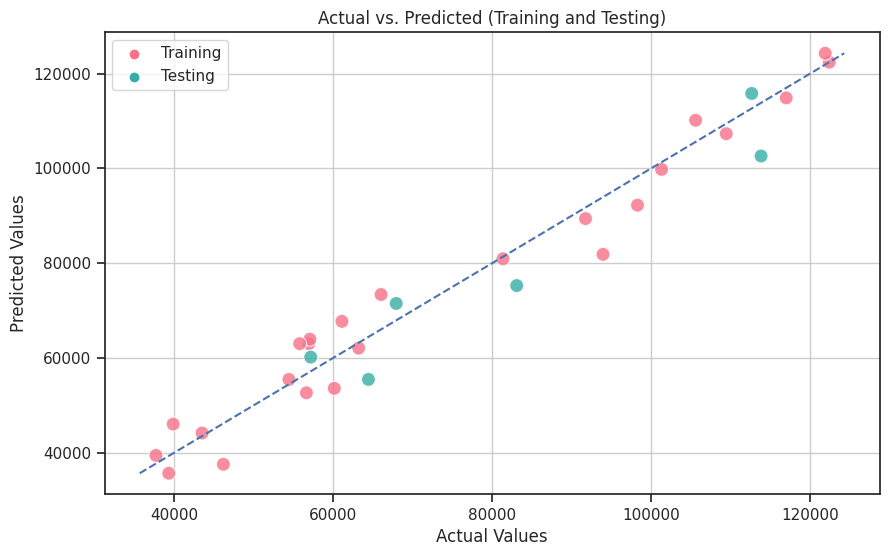

In [15]:
sns.set(style='ticks')
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', hue='Dataset', data=combined_data, s=100, alpha=0.8, palette='husl') 

plt.plot(
    [min(y.min(), y_train_pred.min()) - 1, max(y.max(), y_train_pred.max()) + 1],
    [min(y.min(), y_train_pred.min()) - 1, max(y.max(), y_train_pred.max()) + 1], 
    'b--' 
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted (Training and Testing)')

plt.legend()
plt.grid(True)
plt.show()


# The End